In [168]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torch.optim as optim

import os

In [169]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [170]:
# create train and test splits
df = pd.read_csv('brain_tumor_metadata.csv')
df.head()

,filename,label,PID,source_file,tumor_area
0,1.jpg,0,100360,1,4569
1,10.jpg,0,101016,10,3707
2,100.jpg,0,107494,100,2443
3,1000.jpg,2,112649,1000,1542
4,1001.jpg,2,112649,1001,1757


In [171]:
print(len(df[df['label']==0]))
print(len(df[df['label']==1]))
print(len(df[df['label']==2]))

708
1426
930


In [172]:
from sklearn.model_selection import StratifiedGroupKFold
import pandas as pd

# df must have columns: 'filename', 'label', 'PID'

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# First split off ~15% test, grouped by patient, stratified by label
splits = list(sgkf.split(df, y=df['label'], groups=df['PID']))
train_val_idx, test_idx = splits[0][0], splits[0][1]

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Then split train_val into train/val (~82/18 of the 85%, giving ~70/15 overall), grouped by patient again
sgkf2 = StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=42)  # 1/6 ≈ 15% of remaining 85%
splits2 = list(sgkf2.split(train_val_df, y=train_val_df['label'], groups=train_val_df['PID']))
train_idx, val_idx = splits2[0][0], splits2[0][1]

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

# Sanity check — this must print empty sets
print(set(train_df['PID']) & set(val_df['PID']))
print(set(train_df['PID']) & set(test_df['PID']))
print(set(val_df['PID']) & set(test_df['PID']))

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(train_df['label'].value_counts(normalize=True))
print(val_df['label'].value_counts(normalize=True))

set()
set()
set()
Train: 2042, Val: 409, Test: 613
label
1    0.465230
2    0.303624
0    0.231146
Name: proportion, dtype: float64
label
1    0.464548
2    0.305623
0    0.229829
Name: proportion, dtype: float64


In [173]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import v2
from PIL import Image
from pathlib import Path

# 1. Custom Dataset Definition
class BrainTumorDataset(Dataset):
    def __init__(self, df: pd.DataFrame, base_dir: str | Path, transform=None):
        """
        Args:
            df: DataFrame containing 'filename' and 'label' columns
            base_dir: Path to the directory where folders by label are stored (e.g. './data_jpg')
            transform: PyTorch vision transforms to apply to images
        """
        self.df = df.reset_index(drop=True)
        self.base_dir = Path(base_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Build the exact image path: base_dir / label / filename
        # Ensure label is cast to string in case it's numeric in the DataFrame
        img_path = self.base_dir / str(row['label']+1) / row['filename']
        
        # Load image (convert to RGB in case grayscale images are loaded as 1-channel)
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])
        
        # Apply standard or custom PyTorch transforms
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(label, dtype=torch.long)


# 2. Define Transforms (Image Preprocessing)
# Modern models expect input tensors to be normalized and resized to a uniform size
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    #transforms.RandomHorizontalFlip(), # Basic data augmentation
    transforms.ToTensor(),             # Scales PIL Image [0, 255] to Tensor [0.0, 1.0]
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],    # Standard ImageNet normalization
        std=[0.229, 0.224, 0.225]
    )
])

train_transform_t = v2.Compose([
    v2.RandomRotation(degrees=10),                 # small angle — anatomy is orientation-sensitive
    v2.RandomResizedCrop(224, scale=(0.9, 1.0)),    # mild zoom variation
    v2.ColorJitter(brightness=0.1, contrast=0.1),   # gentle, not aggressive
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = v2.Compose([
    v2.Resize(256),
    v2.CenterCrop(224),
    v2.PILToTensor(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# 3. Instantiate and Wrap in a DataLoader
# Assuming your DataFrame is 'df'
base_path = './data_jpg'
trainset = BrainTumorDataset(df=train_df, base_dir=base_path, transform=train_transform_t)
valset = BrainTumorDataset(df=val_df, base_dir=base_path, transform=val_test_transform)
testset = BrainTumorDataset(df=test_df, base_dir=base_path, transform=train_transform)

trainloader = DataLoader(
    trainset,
    batch_size=32,      # Number of images per batch
    shuffle=True,       # Shuffle at every epoch during training
    num_workers=6,      # Parallel processes for fast data reading
    pin_memory=True     # Faster CPU -> GPU data transfers
)

valloader = DataLoader(
    valset,
    batch_size=32,      # Number of images per batch
    shuffle=True,       # Shuffle at every epoch during training
    num_workers=6,      # Parallel processes for fast data reading
    pin_memory=True 
)

testloader = DataLoader(
    testset,
    batch_size=32,      # Number of images per batch
    shuffle=True,       # Shuffle at every epoch during training
    num_workers=6,      # Parallel processes for fast data reading
    pin_memory=True     # Faster CPU -> GPU data transfers
)

# Quick check: iterate through a single batch
print("Trainloader:")
for images, labels in trainloader:
    print(f"Batch images shape: {images.shape}") # Expect: torch.Size([32, 3, 224, 224])
    print(f"Batch labels shape: {labels.shape}") # Expect: torch.Size([32])
    break

print("\nValloader:")
for images, labels in valloader:
    print(f"Batch images shape: {images.shape}") # Expect: torch.Size([32, 3, 224, 224])
    print(f"Batch labels shape: {labels.shape}") # Expect: torch.Size([32])
    break
    
print("\nTestloader:")
for images, labels in trainloader:
    print(f"Batch images shape: {images.shape}") # Expect: torch.Size([32, 3, 224, 224])
    print(f"Batch labels shape: {labels.shape}") # Expect: torch.Size([32])
    break

Trainloader:
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])

Valloader:
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])

Testloader:
Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


In [174]:
# plot loss curves
import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, val_losses):
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

#plot_loss_curves(train_losses, val_losses)

## Resnet18

In [22]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
num_classes=3
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, model.fc.out_features),  # New hidden layer
    nn.ReLU(),         # Activation
    nn.Dropout(0.5),               # Regularization to prevent overfitting
    nn.Linear(model.fc.out_features, num_classes)    # Final output layer
)

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = torch.optim.AdamW(model.fc.parameters(), lr=0.001)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1426/708, 1, 1426/930]).to(device))

In [23]:
from IPython.display import clear_output

import matplotlib.pyplot as plt

train_losses = []
val_losses = []

epochs = 50

for epoch in range(epochs):
    #print(f"Epoch {epoch}:")
    model.train()
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
    epoch_val_loss = val_running_loss / len(valloader.dataset)
    val_losses.append(epoch_val_loss)

    clear_output(wait=True)
    print(f'Epoch {epoch + 1}/{epochs} - Train loss: {epoch_train_loss:.4f} - Val loss: {epoch_val_loss:.4f}')


# --- 5. PRODUCTION EXPORT ---
print("\n🚀 Training Complete! Exporting model...")

# We strip out the optimizer, scaler, and scheduler to make the file ~3x smaller
export_path = './model/tumor_detection.pth'
torch.save(model.state_dict(), export_path)

print(f"✅ Production model exported to: {export_path}")

Epoch 100/100 - Train loss: 0.0103 - Val loss: 0.6705

🚀 Training Complete! Exporting model...
✅ Production model exported to: ./model/tumor_detection.pth


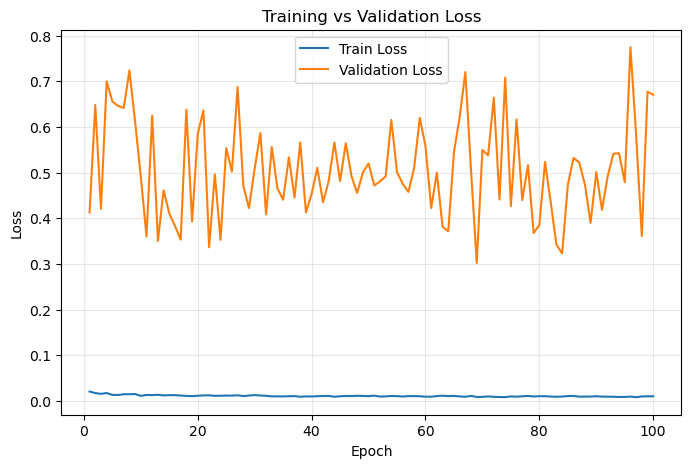

In [24]:
plot_loss_curves(train_losses, val_losses)

In [25]:
correct = 0
total = 0
with torch.no_grad(): # since we aren't training, we don't need to calculate gradients for our outputs
    for data in valloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # get the index of the class with the highest energy for each image in the batch
        total += labels.size(0) # increment total by the number of labels in the batch
        correct += (predicted == labels).sum().item() # increment correct by the number of correct predictions in the batch

print(f'Accuracy of the network on the {total} validation images: {100 * correct / total} %')

Accuracy of the network on the 459 validation images: 84.0958605664488 %


## Resnet50

In [175]:
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.DEFAULT)
num_classes=3
print(model.fc)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),  # New hidden layer
    nn.ReLU(inplace=True),         # Activation
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)    # Final output layer
)

for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = torch.optim.Adam(model.fc.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion = torch.nn.CrossEntropyLoss(weight=torch.tensor([1426/708, 1, 1426/930]).to(device))

Linear(in_features=2048, out_features=1000, bias=True)


In [176]:
# warmup

from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import copy

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

for epoch in range(5):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)  # fixed: weight by batch size

    epoch_train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    val_running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_running_loss / len(valloader.dataset)
    val_losses.append(epoch_val_loss)

    epoch_val_acc = accuracy_score(all_labels, all_preds)
    epoch_val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_accuracies.append(epoch_val_acc)
    val_f1s.append(epoch_val_f1)

    scheduler.step()

    clear_output(wait=True)
    print(f'Epoch {epoch + 1}/{5} - Train loss: {epoch_train_loss:.4f} - '
          f'Val loss: {epoch_val_loss:.4f} - Val acc: {epoch_val_acc:.4f} - '
          f'Val macro-F1: {epoch_val_f1:.4f}')

Epoch 5/5 - Train loss: 0.2819 - Val loss: 0.3785 - Val acc: 0.8337 - Val macro-F1: 0.8278


In [177]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': model.fc.parameters(), 'lr': 5e-4},
    {'params': [p for n, p in model.named_parameters() if not n.startswith('fc')], 'lr': 1e-4}
])

In [178]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import copy

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

epochs = 150
patience = 25  # epochs to wait for improvement before stopping
best_val_loss = float('inf')
best_val_f1 = 0.0
best_model_state = None
epochs_no_improve = 0

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)  # fixed: weight by batch size

    epoch_train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    val_running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_running_loss / len(valloader.dataset)
    val_losses.append(epoch_val_loss)

    epoch_val_acc = accuracy_score(all_labels, all_preds)
    epoch_val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_accuracies.append(epoch_val_acc)
    val_f1s.append(epoch_val_f1)

    

    scheduler.step()

    # ---- Early stopping check ----
    if epoch_val_f1 > best_val_f1:
        best_val_f1 = epoch_val_f1
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    clear_output(wait=True)
    print(f'Epoch {epoch + 1}/{epochs} - Train loss: {epoch_train_loss:.4f} - '
          f'Val loss: {epoch_val_loss:.4f} - Val acc: {epoch_val_acc:.4f} - '
          f'Val macro-F1: {epoch_val_f1:.4f} - No improve: {epochs_no_improve}/{patience}')

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}. "
              f"Best val f1: {best_val_f1:.4f}")
        break

# ---- Restore best weights before export ----
model.load_state_dict(best_model_state)

# --- PRODUCTION EXPORT ---
print("\n🚀 Training Complete! Exporting best model...")
export_path = './model/tumor_detection.pth'
torch.save(model.state_dict(), export_path)
print(f"✅ Production model exported to: {export_path}")

Epoch 70/150 - Train loss: 0.0004 - Val loss: 0.4944 - Val acc: 0.9340 - Val macro-F1: 0.9268 - No improve: 25/25

Early stopping triggered at epoch 70. Best val f1: 0.9374

🚀 Training Complete! Exporting best model...
✅ Production model exported to: ./model/tumor_detection.pth


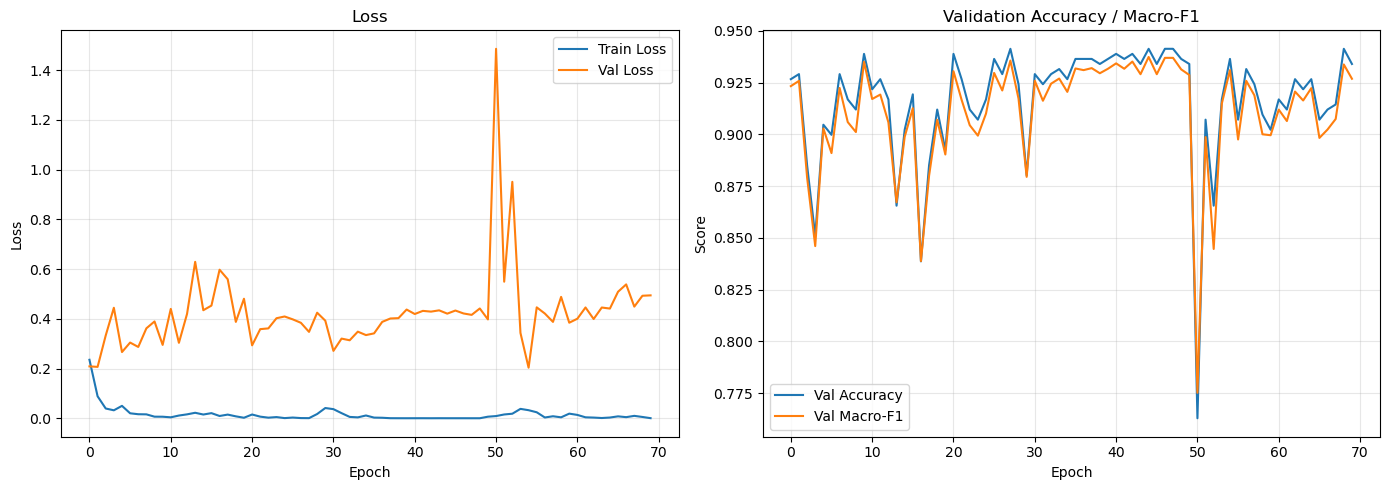

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(val_accuracies, label='Val Accuracy')
axes[1].plot(val_f1s, label='Val Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Accuracy / Macro-F1')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Overall Accuracy: 100.00 %

--- Per-Class Metrics ---
Meningioma:
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

Glioma:
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

pituitary tumor:
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

tensor([[472,   0,   0],
        [  0, 950,   0],
        [  0,   0, 620]])


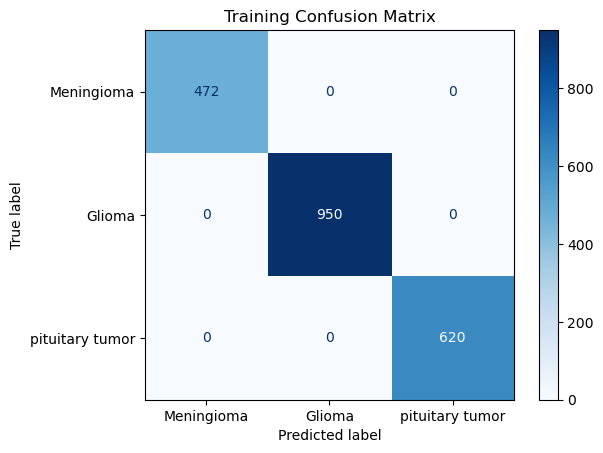

In [180]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

num_classes = 3
class_names = ['Meningioma', 'Glioma', 'pituitary tumor']  # Replace with actual names

# Rows = True label, Columns = Predicted label
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

correct = 0
total = 0

# 1. Evaluation Loop
with torch.no_grad():
    for data in trainloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Populate confusion matrix
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Overall Accuracy
print(f'Overall Accuracy: {100 * correct / total:.2f} %\n')

# 2. Per-Class F1-Score Calculation
print("--- Per-Class Metrics ---")
cm = confusion_matrix.float()

for i in range(num_classes):
    tp = cm[i, i].item()
    fp = (cm[:, i].sum() - tp).item()  # Sum of column minus TP
    fn = (cm[i, :].sum() - tp).item()  # Sum of row minus TP
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"{class_names[i]}:")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}\n")

# 3. Display Visual Confusion Matrix
cm_array = confusion_matrix.cpu().numpy()
print(confusion_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title("Training Confusion Matrix")
plt.show()

Overall Accuracy: 94.13 %

--- Per-Class Metrics ---
Meningioma:
  Precision : 0.8687
  Recall    : 0.9149
  F1-Score  : 0.8912

Glioma:
  Precision : 0.9667
  Recall    : 0.9158
  F1-Score  : 0.9405

pituitary tumor:
  Precision : 0.9615
  Recall    : 1.0000
  F1-Score  : 0.9804

tensor([[ 86,   6,   2],
        [ 13, 174,   3],
        [  0,   0, 125]])


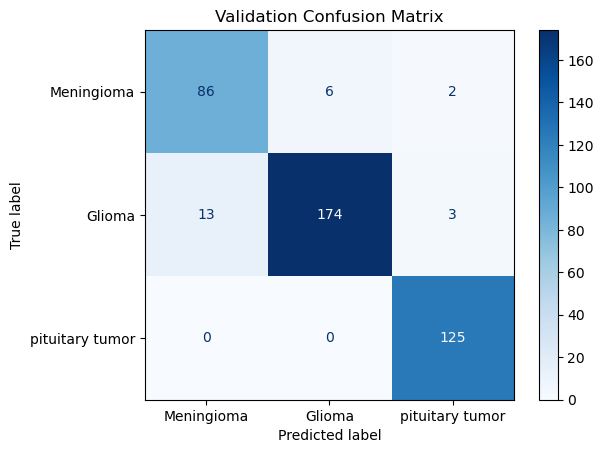

In [181]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

num_classes = 3
class_names = ['Meningioma', 'Glioma', 'pituitary tumor']  # Replace with actual names

# Rows = True label, Columns = Predicted label
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

correct = 0
total = 0

# 1. Evaluation Loop
with torch.no_grad():
    for data in valloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Populate confusion matrix
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Overall Accuracy
print(f'Overall Accuracy: {100 * correct / total:.2f} %\n')

# 2. Per-Class F1-Score Calculation
print("--- Per-Class Metrics ---")
cm = confusion_matrix.float()

for i in range(num_classes):
    tp = cm[i, i].item()
    fp = (cm[:, i].sum() - tp).item()  # Sum of column minus TP
    fn = (cm[i, :].sum() - tp).item()  # Sum of row minus TP
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"{class_names[i]}:")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}\n")

# 3. Display Visual Confusion Matrix
cm_array = confusion_matrix.cpu().numpy()
print(confusion_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title("Validation Confusion Matrix")
plt.show()

In [184]:
import torch
import numpy as np
import pandas as pd

model.eval()
records = []

# valset.df must be in the exact same row order as your DataLoader iterates,
# which only holds if shuffle=False and drop_last=False (confirm both)
flat_idx = 0  

with torch.no_grad():
    for batch_idx, (inputs, labels) in enumerate(valloader):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        confidences = probs.max(dim=1).values

        for i in range(len(labels)):
            # This is the row in val_df that this specific sample came from
            row = valset.df.iloc[flat_idx]

            if preds[i] != labels[i]:
                records.append({
                    'filename': row['filename'],
                    'PID': row['PID'],
                    'tumor_area': row['tumor_area'],
                    'true_label': labels[i].item(),
                    'pred_label': preds[i].item(),
                    'confidence': confidences[i].item(),
                    'prob_meningioma': probs[i][0].item(),
                    'prob_glioma': probs[i][1].item(),
                    'prob_pituitary': probs[i][2].item(),
                })
            flat_idx += 1

misclass_df = pd.DataFrame(records)
misclass_df = misclass_df.sort_values('confidence', ascending=False)
misclass_df

,filename,PID,tumor_area,true_label,pred_label,confidence,prob_meningioma,prob_glioma,prob_pituitary
3,1749.jpg,105187,759,1,0,1.000000,9.999996e-01,2.488725e-07,6.123438e-08
12,2699.jpg,MR032322C,10462,1,0,0.999999,9.999987e-01,8.505002e-07,4.622246e-07
11,2694.jpg,MR032322C,6519,0,1,0.999996,3.342881e-06,9.999956e-01,1.062564e-06
5,2039.jpg,MR051796,4421,1,0,0.999991,9.999908e-01,1.294433e-06,7.814686e-06
17,371.jpg,112252,1764,1,0,0.999986,9.999858e-01,3.350015e-07,1.378140e-05
14,2948.jpg,MR051796,6548,1,0,0.999934,9.999337e-01,1.526765e-05,5.104352e-05
22,669.jpg,97737,4297,1,0,0.999874,9.998735e-01,6.516366e-05,6.122512e-05
16,3037.jpg,MR033389B,2929,1,0,0.999175,9.991745e-01,5.216767e-05,7.732256e-04
0,1280.jpg,114094,6210,0,1,0.999173,7.551729e-04,9.991725e-01,7.228451e-05
6,2165.jpg,MR032322C,12186,1,2,0.999126,2.170539e-09,8.737973e-04,9.991263e-01


KeyError: 'batch_idx'

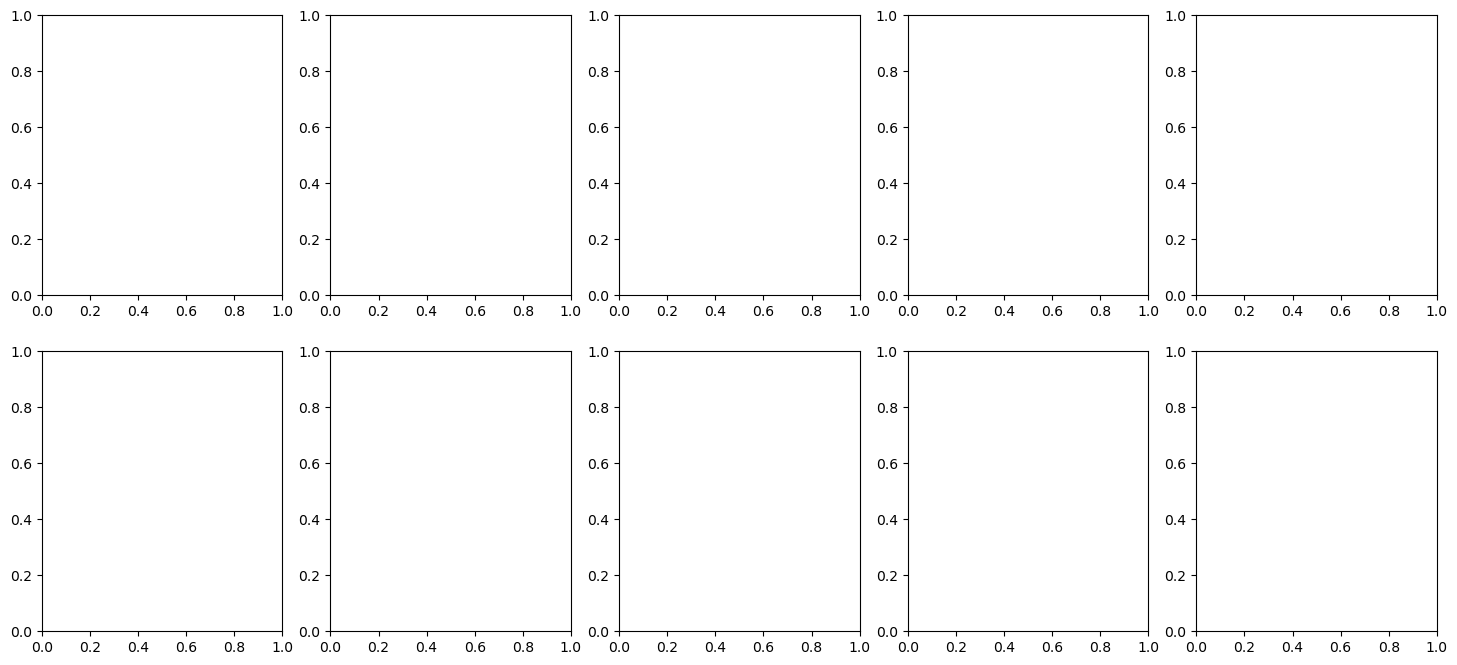

In [185]:
import matplotlib.pyplot as plt

class_names = ['Meningioma', 'Glioma', 'pituitary tumor']

def get_image_by_position(loader, batch_idx, index_in_batch):
    for b_idx, (inputs, labels) in enumerate(loader):
        if b_idx == batch_idx:
            return inputs[int(index_in_batch)]

# Example: look at all Glioma->Meningioma confusions (your most common error)
subset = misclass_df[(misclass_df['true_label'] == 1) & (misclass_df['pred_label'] == 0)]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for ax, (_, row) in zip(axes.flat, subset.iterrows()):
    img = get_image_by_position(valloader, row['batch_idx'], row['index_in_batch'])
    img_display = img.permute(1, 2, 0).numpy()
    img_display = (img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    ax.imshow(np.clip(img_display, 0, 1))
    ax.set_title(f"True: Glioma\nPred: Meningioma\nConf: {row['confidence']:.2f}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [186]:
# pip install grad-cam --break-system-packages
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

img_tensor = get_image_by_position(valloader, row['batch_idx'], row['index_in_batch']).unsqueeze(0).to(device)
grayscale_cam = cam(input_tensor=img_tensor)[0]

img_display = img_tensor[0].cpu().permute(1, 2, 0).numpy()
img_display = np.clip((img_display * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406], 0, 1)

visualization = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)
plt.imshow(visualization)
plt.axis('off')
plt.show()

KeyError: 'batch_idx'

In [188]:
#merged = misclass_df.merge(val_df, left_index=True, right_index=True)  # align carefully by index/filename
print(misclass_df.groupby(['true_label'])['tumor_area'].describe())

            count      mean         std    min      25%     50%       75%  \
true_label                                                                  
0             8.0  6880.875  5184.32482  655.0  2636.00  6364.5  10987.75   
1            16.0  4464.625  3569.17811  509.0  1679.25  3613.0   6568.25   

                max  
true_label           
0           15220.0  
1           12186.0  


In [ ]:
merged

In [189]:
print(misclass_df['PID'].value_counts())

PID
MR032322C    3
105187       2
MR051796     2
MR033389B    2
MR026175E    2
112252       1
114094       1
MR049019C    1
113435       1
97737        1
MR038469     1
MR034694     1
100639       1
112002       1
104912       1
97481        1
104167       1
100820       1
Name: count, dtype: int64


### Erorrs?

In [192]:
all_records = []
flat_idx = 0
with torch.no_grad():
    for inputs, labels in valloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        confidences = probs.max(dim=1).values

        for i in range(len(labels)):
            row = valset.df.iloc[flat_idx]
            all_records.append({
                'filename': row['filename'],
                'PID': row['PID'],
                'tumor_area': row['tumor_area'],
                'true_label': labels[i].item(),
                'pred_label': preds[i].item(),
                'correct': int(preds[i].item() == labels[i].item()),
                'confidence': confidences[i].item(),
            })
            flat_idx += 1

full_val_df = pd.DataFrame(all_records)
full_val_df
merged_df = full_val_df

In [193]:
import pandas as pd
import numpy as np
from scipy import stats

# Assumes you have a dataframe with columns:
# 'tumor_area' (pixel count from tumorMask.sum())
# 'correct' (1 if prediction matches true label, 0 otherwise)
# 'confidence' (max softmax probability)
# 'true_label', 'pred_label', 'PID'

#df = pd.read_csv('val_predictions_with_area.csv')  # however you've built this

# 1. Point-biserial correlation: tumor area vs. correctness
r_pb, p_pb = stats.pointbiserialr(merged_df['correct'], merged_df['tumor_area'])
print(f"Point-biserial (area vs correct): r={r_pb:.4f}, p={p_pb:.4f}")

# 2. Pearson + Spearman: tumor area vs. confidence
r_pearson, p_pearson = stats.pearsonr(merged_df['tumor_area'], merged_df['confidence'])
r_spearman, p_spearman = stats.spearmanr(merged_df['tumor_area'], merged_df['confidence'])
print(f"Pearson (area vs confidence): r={r_pearson:.4f}, p={p_pearson:.4f}")
print(f"Spearman (area vs confidence): r={r_spearman:.4f}, p={p_spearman:.4f}")

# 3. Direct group comparison: are misclassified images' tumor areas
#    significantly smaller than correctly classified ones?
correct_areas = merged_df[merged_df['correct'] == 1]['tumor_area']
incorrect_areas = merged_df[merged_df['correct'] == 0]['tumor_area']

t_stat, p_ttest = stats.ttest_ind(correct_areas, incorrect_areas, equal_var=False)
u_stat, p_mannwhitney = stats.mannwhitneyu(correct_areas, incorrect_areas, alternative='greater')

print(f"\nMean tumor area (correct): {correct_areas.mean():.1f}")
print(f"Mean tumor area (incorrect): {incorrect_areas.mean():.1f}")
print(f"Median tumor area (correct): {correct_areas.median():.1f}")
print(f"Median tumor area (incorrect): {incorrect_areas.median():.1f}")
print(f"Welch's t-test: t={t_stat:.3f}, p={p_ttest:.4f}")
print(f"Mann-Whitney U (correct > incorrect): p={p_mannwhitney:.4f}")

Point-biserial (area vs correct): r=-0.0453, p=0.3608
Pearson (area vs confidence): r=-0.0222, p=0.6550
Spearman (area vs confidence): r=-0.0137, p=0.7823

Mean tumor area (correct): 4441.2
Mean tumor area (incorrect): 5275.6
Median tumor area (correct): 3025.0
Median tumor area (incorrect): 3629.5
Welch's t-test: t=-0.807, p=0.4274
Mann-Whitney U (correct > incorrect): p=0.8562


In [197]:
# Flag slices with little/no visible tumor
merged_df['near_zero_tumor'] = merged_df['tumor_area'] < 1000  # pick a threshold — visualize the distribution first to pick sensibly

# Cross-tab: error rate for near-zero-tumor slices vs. the rest
crosstab = pd.crosstab(merged_df['near_zero_tumor'], merged_df['correct'], normalize='index')
print(crosstab)

# Chi-square test: is error rate independent of near-zero-tumor status?
contingency = pd.crosstab(merged_df['near_zero_tumor'], merged_df['correct'])
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square: chi2={chi2:.3f}, p={p_chi2:.4f}")

correct                 0         1
near_zero_tumor                    
False            0.066092  0.933908
True             0.016393  0.983607

Chi-square: chi2=1.508, p=0.2194


In [198]:
merged_df.to_csv('validation_results.csv', index=True)

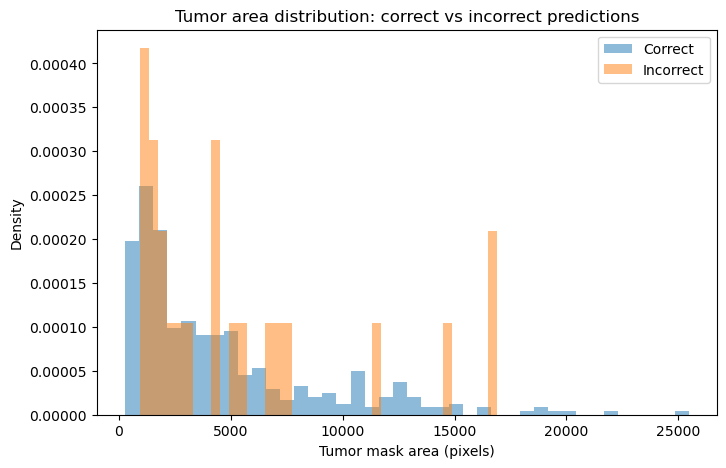

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(merged_df[merged_df['correct']==1]['tumor_area'], bins=40, alpha=0.5, label='Correct', density=True)
plt.hist(merged_df[merged_df['correct']==0]['tumor_area'], bins=40, alpha=0.5, label='Incorrect', density=True)
plt.xlabel('Tumor mask area (pixels)')
plt.ylabel('Density')
plt.legend()
plt.title('Tumor area distribution: correct vs incorrect predictions')
plt.show()

## Resnet152

In [67]:
from torchvision.models import resnet152, ResNet152_Weights

model = resnet152(weights=ResNet152_Weights.DEFAULT)
model.layer4

Sequential(
  (0): Bottleneck(
    (conv1): Conv2d(1024, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (downsample): Sequential(
      (0): Conv2d(1024, 2048, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): Bottleneck(
    (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): 

In [85]:
from torchvision.models import resnet152, ResNet152_Weights

model = resnet152(weights=ResNet152_Weights.DEFAULT)
num_classes=3
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),  # New hidden layer
    nn.ReLU(),         # Activation,
    nn.Dropout(0.15),
    nn.Linear(256, num_classes)    # Final output layer
)

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

optimizer = torch.optim.AdamW([{'params': model.fc.parameters(), 'lr': 3e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-5},])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)
criterion = torch.nn.CrossEntropyLoss(weight=torch.sqrt(torch.tensor([1426/708, 1, 1426/930])).to(device))

In [86]:
from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
import copy

train_losses = []
val_losses = []
val_accuracies = []
val_f1s = []

epochs = 150
patience = 30  # epochs to wait for improvement before stopping
best_val_loss = float('inf')
best_model_state = None
epochs_no_improve = 0

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)  # fixed: weight by batch size

    epoch_train_loss = running_loss / len(trainloader.dataset)
    train_losses.append(epoch_train_loss)

    # ---- Validation ----
    model.eval()
    val_running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_val_loss = val_running_loss / len(valloader.dataset)
    val_losses.append(epoch_val_loss)

    epoch_val_acc = accuracy_score(all_labels, all_preds)
    epoch_val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_accuracies.append(epoch_val_acc)
    val_f1s.append(epoch_val_f1)

    scheduler.step(epoch_val_loss)

    # ---- Early stopping check ----
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    clear_output(wait=True)
    print(f'Epoch {epoch + 1}/{epochs} - Train loss: {epoch_train_loss:.4f} - '
          f'Val loss: {epoch_val_loss:.4f} - Val acc: {epoch_val_acc:.4f} - '
          f'Val macro-F1: {epoch_val_f1:.4f} - No improve: {epochs_no_improve}/{patience}')

    if epochs_no_improve >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}. "
              f"Best val loss: {best_val_loss:.4f}")
        break

# ---- Restore best weights before export ----
model.load_state_dict(best_model_state)

# --- PRODUCTION EXPORT ---
print("\n🚀 Training Complete! Exporting best model...")
export_path = './model/tumor_detection.pth'
torch.save(model.state_dict(), export_path)
print(f"✅ Production model exported to: {export_path}")

Epoch 54/150 - Train loss: 0.0392 - Val loss: 0.4435 - Val acc: 0.8736 - Val macro-F1: 0.8567 - No improve: 30/30

Early stopping triggered at epoch 54. Best val loss: 0.2641

🚀 Training Complete! Exporting best model...
✅ Production model exported to: ./model/tumor_detection.pth


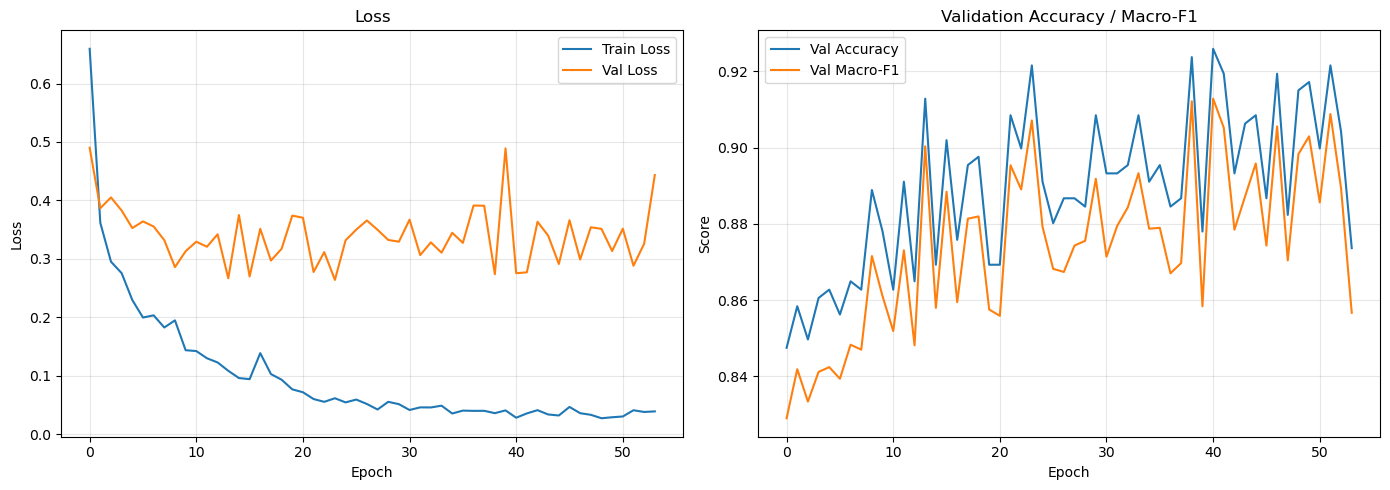

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(val_accuracies, label='Val Accuracy')
axes[1].plot(val_f1s, label='Val Macro-F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Accuracy / Macro-F1')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Overall Accuracy: 98.97 %

--- Per-Class Metrics ---
Meningioma:
  Precision : 0.9818
  Recall    : 0.9778
  F1-Score  : 0.9798

Glioma:
  Precision : 0.9880
  Recall    : 0.9940
  F1-Score  : 0.9910

pituitary tumor:
  Precision : 0.9985
  Recall    : 0.9923
  F1-Score  : 0.9954

tensor([[485,  10,   1],
        [  6, 992,   0],
        [  3,   2, 646]])


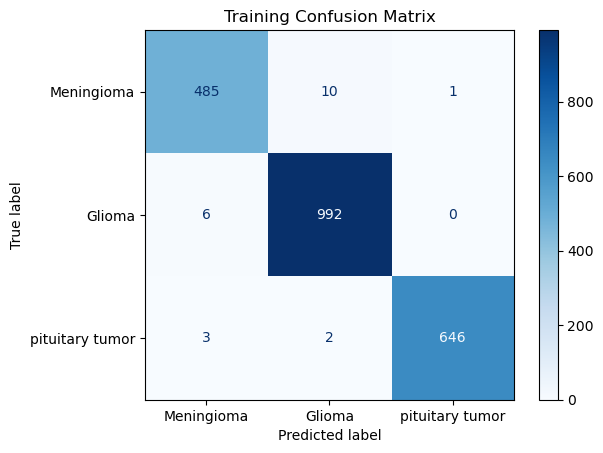

In [88]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

num_classes = 3
class_names = ['Meningioma', 'Glioma', 'pituitary tumor']  # Replace with actual names

# Rows = True label, Columns = Predicted label
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

correct = 0
total = 0

# 1. Evaluation Loop
with torch.no_grad():
    for data in trainloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Populate confusion matrix
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Overall Accuracy
print(f'Overall Accuracy: {100 * correct / total:.2f} %\n')

# 2. Per-Class F1-Score Calculation
print("--- Per-Class Metrics ---")
cm = confusion_matrix.float()

for i in range(num_classes):
    tp = cm[i, i].item()
    fp = (cm[:, i].sum() - tp).item()  # Sum of column minus TP
    fn = (cm[i, :].sum() - tp).item()  # Sum of row minus TP
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"{class_names[i]}:")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}\n")

# 3. Display Visual Confusion Matrix
cm_array = confusion_matrix.cpu().numpy()
print(confusion_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title("Training Confusion Matrix")
plt.show()

Overall Accuracy: 92.16 %

--- Per-Class Metrics ---
Meningioma:
  Precision : 0.8600
  Recall    : 0.8113
  F1-Score  : 0.8350

Glioma:
  Precision : 0.9950
  Recall    : 0.9346
  F1-Score  : 0.9639

pituitary tumor:
  Precision : 0.8671
  Recall    : 0.9856
  F1-Score  : 0.9226

tensor([[ 86,   1,  19],
        [ 12, 200,   2],
        [  2,   0, 137]])


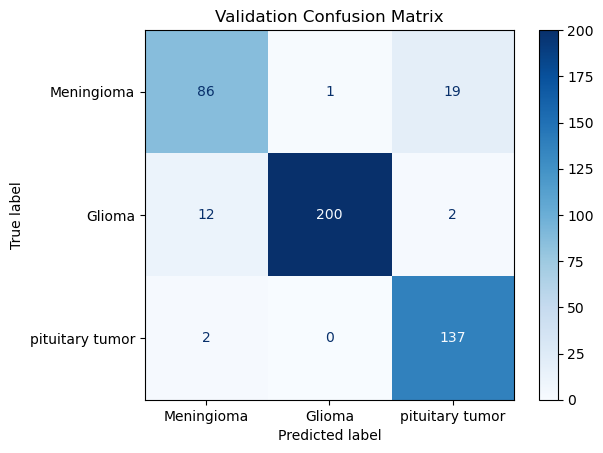

In [89]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

num_classes = 3
class_names = ['Meningioma', 'Glioma', 'pituitary tumor']  # Replace with actual names

# Rows = True label, Columns = Predicted label
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

correct = 0
total = 0

# 1. Evaluation Loop
with torch.no_grad():
    for data in valloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Populate confusion matrix
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Overall Accuracy
print(f'Overall Accuracy: {100 * correct / total:.2f} %\n')

# 2. Per-Class F1-Score Calculation
print("--- Per-Class Metrics ---")
cm = confusion_matrix.float()

for i in range(num_classes):
    tp = cm[i, i].item()
    fp = (cm[:, i].sum() - tp).item()  # Sum of column minus TP
    fn = (cm[i, :].sum() - tp).item()  # Sum of row minus TP
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"{class_names[i]}:")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}\n")

# 3. Display Visual Confusion Matrix
cm_array = confusion_matrix.cpu().numpy()
print(confusion_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title("Validation Confusion Matrix")
plt.show()

## Test

In [207]:
model = resnet50()
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),  # New hidden layer
    nn.ReLU(inplace=True),         # Activation
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)    # Final output layer
)
checkpoint = torch.load('./model/tumor_detection.pth', map_location=device)
model.load_state_dict(checkpoint)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Overall Test Accuracy: 95.92 %

--- Per-Class Metrics ---
Meningioma:
  Precision : 0.8679
  Recall    : 0.9718
  F1-Score  : 0.9169

Glioma:
  Precision : 0.9928
  Recall    : 0.9580
  F1-Score  : 0.9751

pituitary tumor:
  Precision : 0.9888
  Recall    : 0.9514
  F1-Score  : 0.9697

tensor([[138,   2,   2],
        [ 12, 274,   0],
        [  9,   0, 176]])


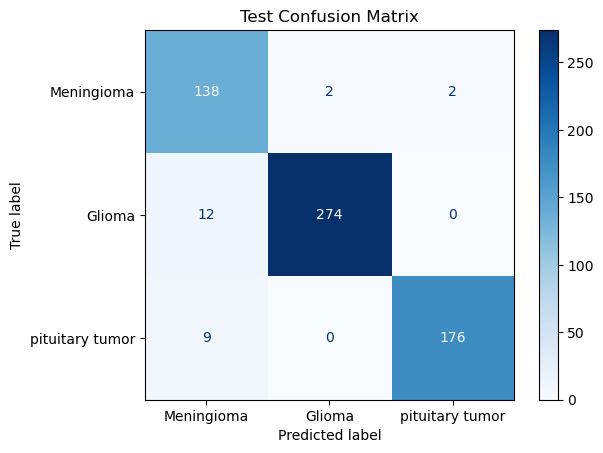

In [208]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

num_classes = 3
class_names = ['Meningioma', 'Glioma', 'pituitary tumor']  # Replace with actual names

# Rows = True label, Columns = Predicted label
confusion_matrix = torch.zeros(num_classes, num_classes, dtype=torch.int64)

correct = 0
total = 0

# 1. Evaluation Loop
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Populate confusion matrix
        for t, p in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[t.long(), p.long()] += 1

# Overall Accuracy
print(f'Overall Test Accuracy: {100 * correct / total:.2f} %\n')

# 2. Per-Class F1-Score Calculation
print("--- Per-Class Metrics ---")
cm = confusion_matrix.float()

for i in range(num_classes):
    tp = cm[i, i].item()
    fp = (cm[:, i].sum() - tp).item()  # Sum of column minus TP
    fn = (cm[i, :].sum() - tp).item()  # Sum of row minus TP
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    print(f"{class_names[i]}:")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1-Score  : {f1:.4f}\n")

# 3. Display Visual Confusion Matrix
cm_array = confusion_matrix.cpu().numpy()
print(confusion_matrix)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_array, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)

plt.title("Test Confusion Matrix")
plt.show()